<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/4_2_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson 4 – Distributions, Missing Values, and Outliers 2

The next topic of the lesson:

- **Handling missing values**.  
- We will examine how missing values appear in both numerical and categorical variables, and how they affect the distribution and summary statistics.  
- We will present basic imputation strategies and their consequences.


### Wine Dataset

The Wine dataset is a classic and frequently used dataset  
that describes wines based on various chemical measurements.  
Each row represents a wine sample, and the columns contain  
numerical features derived from laboratory measurements.

The data belong to three different wine types,  
which makes the dataset well suited for examining distributions,  
relationships between variables, and correlations.

### Wine Dataset – Explanation of the Feature Set

The Wine dataset contains **178 wine samples**, each described by **13 chemical features** and one **target variable**.  
The goal is to identify the **type (class) of wine** based on its chemical composition.

### Chemical Features

- **alcohol** – alcohol content  
- **alcohol_noise** – alcohol content **with added noise**  
- **malic_acid** – amount of malic acid (one component of acidity)  
- **malic_acid_noise** – amount of malic acid **with added noise**  
- **ash** – ash content (amount of mineral substances)  
- **ash_noise** – ash content **with added noise**  
- **alcalinity_of_ash** – alkalinity of ash  
- **magnesium** – magnesium content  
- **magnesium_noise** – magnesium content **with added noise**  
- **total_phenols** – total amount of phenolic compounds  
- **flavanoids** – amount of flavonoids (flavor, antioxidants)  
- **nonflavanoid_phenols** – non-flavonoid phenols  
- **proanthocyanins** – proanthocyanins (color, astringency)  
- **color_intensity** – color intensity  
- **hue** – color tone  
- **od280/od315_of_diluted_wines** – optical density ratio, related to aroma and phenols  
- **proline** – amount of the amino acid proline (often a strong varietal indicator)

### Target Variable

- **target** – wine type (category), typically **3 different classes**

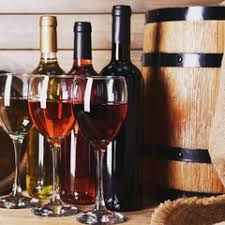

In [ ]:
# Load the WINE dataset
# The Wine dataset is a classic, fully numerical dataset
# that is often used for teaching statistical analysis and machine learning.

from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

# Load data
file_id = "1_A6F7SxeFGh6-u-MvSl39uFSGD6o1C2x"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_pickle(url)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,alcohol_noise,malic_acid_noise,ash_noise,magnesium_noise
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,14.254836,1.696767,2.429074,127.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,13.193087,1.916008,2.125567,100.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,13.192384,2.391283,2.686136,101.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,14.446151,1.907142,2.458638,113.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,13.228292,2.536455,2.895967,NaN


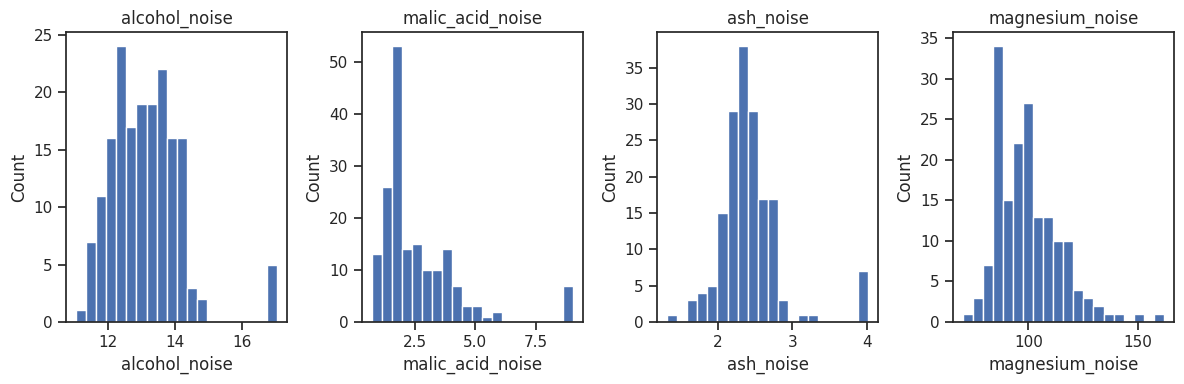

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn base style
# The "ticks" style provides clean axes and readable tick marks
sns.set(style="ticks")

# Columns whose distributions we want to compare
noise_columns = ["alcohol_noise", "malic_acid_noise", "ash_noise", "magnesium_noise"]

# Create a figure with 1 row and multiple columns (subplots) so the histograms appear side by side
fig, axes = plt.subplots(1, len(noise_columns), figsize=(12, 4))

for ax, col in zip(axes, noise_columns):
    # Draw a histogram on the given axis (ax)
    df[col].plot(kind="hist", ax=ax, bins=20)

    # Set axis labels and title
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()  # adjust layout so labels do not overlap
plt.show()          # display the figure

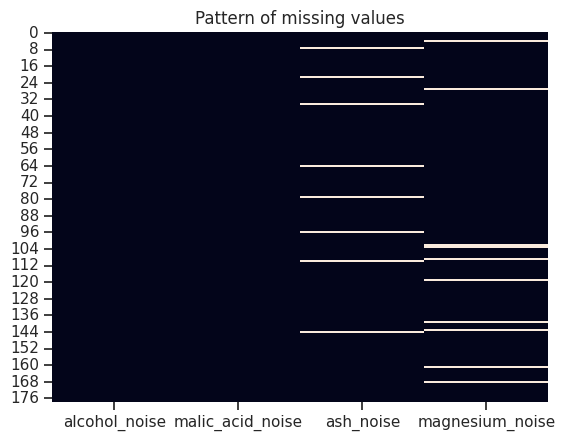

In [ ]:
# Let us examine the pattern of missing values (NaN).
# If outliers were previously replaced with NaN, this also shows the effect of outlier handling.
sns.heatmap(df[noise_columns].isna(), cbar=False)
plt.title("Pattern of missing values")
plt.show()

### Handling Missing Numerical Values

Missing numerical values (`NaN`) are common in real-world datasets.  
Handling missing values is not just a technical issue: it affects the distribution, the mean,  
and later the modeling process as well.

In this section, we will examine where missing values appear,  
and then compare two simple imputation strategies (**mean vs. median**).

In [ ]:
# Check where missing values occur (count per column)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

,0
magnesium_noise,10
ash_noise,8


In [ ]:
col = "ash_noise"

## Imputing Missing Values with `fillna()`

The `fillna()` function is used to replace missing values (`NaN`) according to a chosen rule.

Common methods include:

- **Constant value**: e.g., `0`, `"unknown"`, `-1`
- **Mean / median**: typical for numerical columns

Important:

- With mean/median imputation, the distribution may become distorted (especially when there are many missing values).

In [ ]:
# Create two separate DataFrames so we can compare the imputation methods:
# - df_mean: missing values replaced with the mean
# - df_median: missing values replaced with the median
df_mean = df.copy()
df_median = df.copy()

# Calculate the mean and median of the selected column (col)
# (these will be the replacement values)
mean_value = df[col].mean()
median_value = df[col].median()

# Replace missing values:
# fillna(...) substitutes the given value in place of NaN
df_mean[col] = df_mean[col].fillna(mean_value)
df_median[col] = df_median[col].fillna(median_value)

# As a check, print the two replacement values (mean vs median)
# (if the distribution is skewed or contains outliers, the mean and median may differ)
mean_value, median_value

(np.float64(2.4239380011762273), 2.3547242071873997)

In [ ]:
# Compare describe statistics
desc = pd.concat(
    {
        "Original (with missing values)": df[col].describe(),
        "Imputed with mean": df_mean[col].describe(),
        "Imputed with median": df_median[col].describe(),
    },
    axis=1
)

display(desc)

,Original (with missing values),Imputed with mean,Imputed with median
count,170.000000,178.000000,178.000000
mean,2.423938,2.423938,2.420827
std,0.426732,0.416976,0.417224
min,1.322576,1.322576,1.322576
25%,2.216777,2.223557,2.223557
50%,2.354724,2.375251,2.354724
75%,2.580208,2.561119,2.561119
max,4.015698,4.015698,4.015698


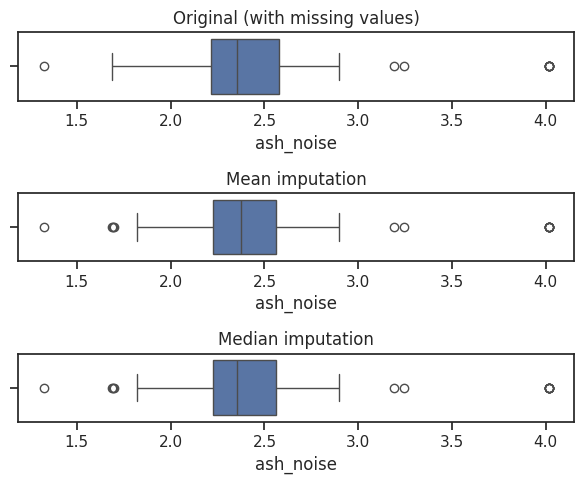

In [ ]:
# Visual comparison of the distributions (boxplot)
fig, axes = plt.subplots(3, 1, figsize=(6, 5))

sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title("Original (with missing values)")

sns.boxplot(x=df_mean[col], ax=axes[1])
axes[1].set_title("Mean imputation")

sns.boxplot(x=df_median[col], ax=axes[2])
axes[2].set_title("Median imputation")

plt.tight_layout()
plt.show()


**Key idea**

- Imputing missing numerical values can change the distribution.  
- **Mean imputation** is more sensitive to outliers, while **median imputation**  
  is generally more robust when the distribution is skewed or contains outliers.  
- Most importantly, the choice of imputation method always depends on the context,  
  because it influences the conclusions drawn from the data.


### Categorical Data and Missing Values

Handling categorical variables differs from numerical data:
- here we do not calculate means or medians, but instead think in terms of groups.

In this section, we will artificially create a categorical column from a numerical variable and then introduce missing values.


In [ ]:
# Create a categorical column from a numerical variable
df_cat = df.copy()

df_cat["alcohol_category"] = pd.cut(
                                        df_cat["alcohol_noise"],
                                        bins=[0, 12.5, 13.5, df_cat["alcohol_noise"].max()],
                                        labels=["low", "medium", "high"]
                                    )

df_cat[["alcohol_noise", "alcohol_category"]].head()


,alcohol_noise,alcohol_category
0,14.254836,high
1,13.193087,medium
2,13.192384,medium
3,14.446151,high
4,13.228292,medium


In [ ]:
# Insert random missing values (NaN)
# For reproducibility
np.random.seed(42)

# Select random indices
na_idx = np.random.choice(
    df_cat.index,
    size=10,
    replace=False
)

# Replace categorical values with NaN
df_cat.loc[na_idx, "alcohol_category"] = np.nan

df_cat["alcohol_category"].tail(10)



,alcohol_category
168,high
169,medium
170,low
171,medium
172,high
173,high
174,NaN
175,medium
176,medium
177,high


In [ ]:
# Overview of the values in the categorical column
df_cat["alcohol_category"].value_counts(dropna=False)


,count
alcohol_category,
medium,58
high,57
low,53
NaN,10


**Mode-based imputation** (most frequent category)

In [ ]:
# Create a copy
df_mode = df_cat.copy()

# Determine the most frequent category
mode_value = df_mode["alcohol_category"].mode()[0]

# Replace missing values with the most frequent category
df_mode["alcohol_category"] = df_mode["alcohol_category"].fillna(mode_value)

mode_value


'medium'

In [ ]:
df_mode["alcohol_category"].value_counts()


,count
alcohol_category,
medium,68
high,57
low,53


**Introducing an "unknown"** (or **"missing"**) **category**

In [ ]:
# Create a copy
df_unknown = df_cat.copy()

# Replace missing values with a new category
df_unknown["alcohol_category"] = df_unknown["alcohol_category"].cat.add_categories("unknown")
df_unknown["alcohol_category"] = df_unknown["alcohol_category"].fillna("unknown")


In [ ]:
df_unknown["alcohol_category"].value_counts()


,count
alcohol_category,
medium,58
high,57
low,53
unknown,10


**Keeping missing values** (a deliberate decision)

In [ ]:
# Keep the original state
df_keep_na = df_cat.copy()

df_keep_na["alcohol_category"].value_counts(dropna=False)


,count
alcohol_category,
medium,58
high,57
low,53
NaN,10


**Key idea**

- In categorical data, handling missing values is always an interpretative decision.  
- Mode-based imputation is simple, the **"unknown"** category can be informative, and keeping missing values can be a deliberate analytical choice.  
- There is no universally “correct” solution—only strategies that fit the given task better or worse.

## Dropping Missing Values with `dropna()`

It is not always necessary to replace missing values (`fillna` / imputation).  
If we **have enough data** and the proportion of missing values is small, it is often simpler and cleaner to **drop** the affected rows or columns.

The `dropna()` function does exactly this: it removes rows or columns that contain missing values.

Common options:

- `df.dropna()`  
  Drops every row where *any* column contains a missing value.

- `df.dropna(subset=[...])`  
  Only considers missing values in specific columns.  
  For example: “if `age` is missing, drop the row, but if `cabin` is missing, we do not care”.

- `df.dropna(axis=1)`  
  Drops columns if they contain missing values  
  (used less frequently because it may cause significant data loss).

- `how="any"` vs `how="all"`  
  - `any` (default): drop if there is a NaN *anywhere* in the row  
  - `all`: drop only if *all* values are NaN

**When is `dropna()` useful?**

- when the number of missing values is small (e.g., 1–5%)  
- when the missing values appear randomly  
- when it is important to work with a “clean” dataset

**When can it be risky?**

- if many rows are removed (loss of data)  
- if the missingness is not random (the absence itself may carry information)  
- if it introduces bias (e.g., disproportionately removing rows from certain groups)

In [ ]:
# Number of missing values per column (in descending order)
missing_per_col = df.isna().sum().sort_values(ascending=False)
display(missing_per_col[missing_per_col > 0])


,0
magnesium_noise,10
ash_noise,8


In [ ]:
# Which columns are affected? (these contain at least one NaN)
cols_with_missing = list(missing_per_col[missing_per_col > 0].index)
print("Columns with missing values:", cols_with_missing)

print("Number of rows in the original dataset:", len(df))

# dropna() – drops every row that contains NaN anywhere
df_drop_any = df.dropna()
print("Number of rows after dropna():", len(df_drop_any))

# dropna(subset=...) – drop rows only based on the columns with missing values
# (this will often be the same as simple dropna, but here the logic is explicit)
df_drop_subset = df.dropna(subset=cols_with_missing)
print("Number of rows after dropna(subset=columns with missing values):", len(df_drop_subset))



Columns with missing values: ['magnesium_noise', 'ash_noise']
Number of rows in the original dataset: 178
Number of rows after dropna(): 160
Number of rows after dropna(subset=columns with missing values): 160


### Exercises – Diabetes Dataset

- For the following exercises, we will use the `diabetes` dataset.  
- This is a real medical measurement dataset that is particularly suitable for examining distributions, missing values, and outliers.  
- The goal is not modeling, but understanding the data and preparing it consciously.


### Brief Introduction to the Diabetes Dataset

The diabetes dataset contains numerical variables derived from clinical measurements  
that describe the health status of patients with diabetes.  
Each column represents standardized values of different physiological characteristics  
(e.g., body mass index, blood pressure, blood-related parameters).

The target variable of the dataset represents the **progression of the disease**,  
measured one year after the initial measurements.  
The dataset is particularly suitable for examining **distributions**, **outliers**,  
and **data quality issues**.


### Columns of the Diabetes Dataset

Each row of the dataset corresponds to a patient, while the columns describe  
different standardized health-related features:

- **age** – age (standardized)  
- **sex** – sex (standardized encoded value)  
- **bmi** – body mass index (BMI)  
- **bp** – blood pressure  
- **s1–s6** – various laboratory measurements related to blood chemistry and metabolism  
- **target** – progression of the disease one year later

All input variables are **numerical and standardized**,  
which makes the dataset well suited for statistical analysis and distribution exploration.

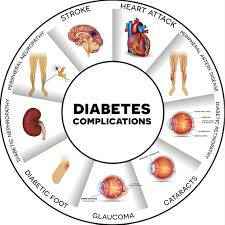

In [ ]:
# Load the diabetes dataset
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes(as_frame=True)
df_diab = diabetes.frame.copy()

display(df_diab.head())


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
noise_columns = ['bp', 'bp', 'bmi', 'age']
# Introduce missing values in randomly selected rows
for col in noise_columns:
    na_idx = np.random.choice(df_diab.index, size=20, replace=False)
    df_diab.loc[na_idx, col] = np.nan

In [ ]:
# Basic information
df_diab.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     413 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     412 non-null    float64
 3   bp      386 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


### Task 1

For a numerical variable that contains missing values:

- create two versions (**mean imputation** and **median imputation**),
- visualize the differences using **boxplots**.

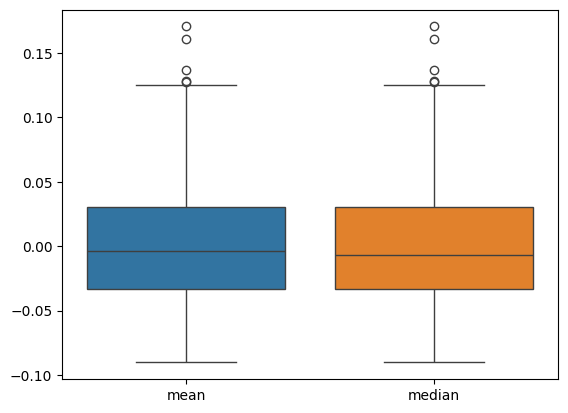

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df_diab = diabetes.frame.copy()

noise_columns = ['bp', 'bp', 'bmi', 'age']
for col in noise_columns:
    na_idx = np.random.choice(df_diab.index, size=20, replace=False)
    df_diab.loc[na_idx, col] = np.nan

mean_imputed = df_diab['bmi'].fillna(df_diab['bmi'].mean())
median_imputed = df_diab['bmi'].fillna(df_diab['bmi'].median())

sns.boxplot(data=pd.DataFrame({"mean": mean_imputed, "median": median_imputed}))
plt.show()

### Task 2

Create a categorical variable from a numerical column using `pd.cut`.

Then:

- randomly overwrite some values with `NaN`,
- create 3 versions:
  - **mode-based imputation**
  - **"unknown" category**
  - **keeping the missing values**
- compare the proportions of the categories.


In [5]:
cat = pd.cut(df_diab['age'], bins=3, labels=["low","medium","high"])
cat_nan = cat.copy()

na_idx = np.random.choice(cat_nan.index, size=20, replace=False)
cat_nan.iloc[na_idx] = np.nan

mode_imputed = cat_nan.fillna(cat_nan.mode()[0])
unknown_imputed = cat_nan.cat.add_categories("unknown").fillna("unknown")

print(mode_imputed.value_counts(normalize=True))
print(unknown_imputed.value_counts(normalize=True))
print(cat_nan.value_counts(normalize=True, dropna=False))

age
medium    0.542986
low       0.237557
high      0.219457
Name: proportion, dtype: float64
age
medium     0.454751
low        0.237557
high       0.219457
unknown    0.088235
Name: proportion, dtype: float64
age
medium    0.454751
low       0.237557
high      0.219457
NaN       0.088235
Name: proportion, dtype: float64


## Task 3 – The Effect of Missing Values on the Distribution of BMI

The `bmi` variable contains the standardized value of body mass index.

1. Plot the distribution of `bmi` using a histogram or boxplot.  
2. Create a new DataFrame in which approximately 15% of the `bmi` values are set to `NaN`.  
3. Plot the distribution again.  
4. Replace the missing values with the mean (`fillna(mean)`), then create the plot again.  
5. Repeat the imputation using the median (`fillna(median)`).

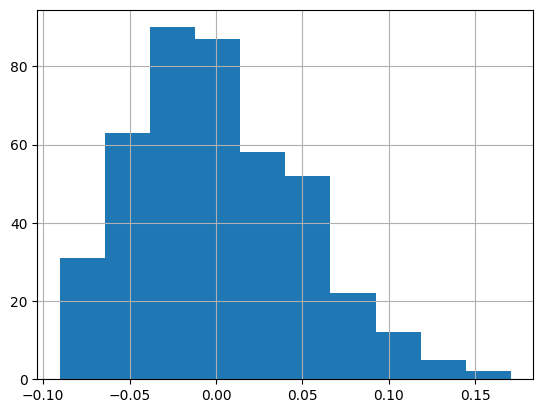

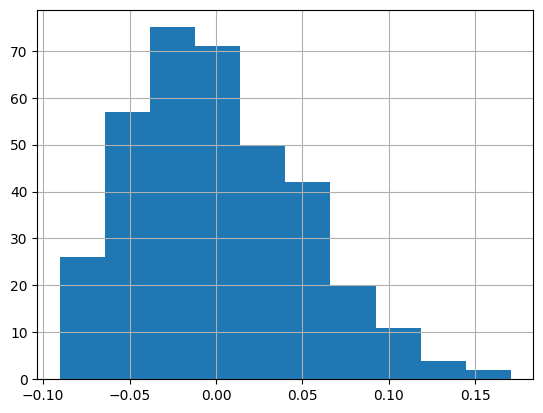

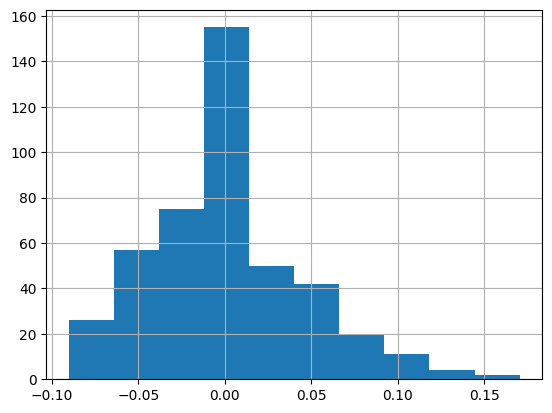

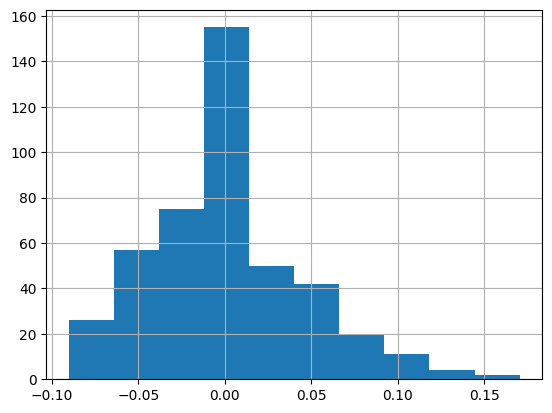

In [3]:
df_bmi = df_diab.copy()

df_bmi['bmi'].hist()
plt.show()

na_idx = np.random.choice(df_bmi.index, size=int(0.15*len(df_bmi)), replace=False)
df_bmi.loc[na_idx, 'bmi'] = np.nan

df_bmi['bmi'].hist()
plt.show()

mean_imp = df_bmi['bmi'].fillna(df_bmi['bmi'].mean())
mean_imp.hist()
plt.show()

median_imp = df_bmi['bmi'].fillna(df_bmi['bmi'].median())
median_imp.hist()
plt.show()

## Task 4 – Creating Categories and Handling Missing Values

The `age` variable contains the standardized age values of the patients.

1. Create a new categorical variable called `age_group` using `pd.cut()`.  
   For example, define three categories: **low**, **medium**, and **high** values.

2. Check how many observations belong to each category using `value_counts()`.

3. Handle the missing values in two different ways:
   - replace them with the most frequent category (`mode`)
   - replace them with a new category (`"unknown"`)

4. Compare the results.

In [6]:
age_group = pd.cut(df_diab['age'], bins=3, labels=["low","medium","high"])
print(age_group.value_counts())

mode_filled = age_group.fillna(age_group.mode()[0])
unknown_filled = age_group.cat.add_categories("unknown").fillna("unknown")

print(mode_filled.value_counts())
print(unknown_filled.value_counts())

age
medium    211
low       111
high      100
Name: count, dtype: int64
age
medium    231
low       111
high      100
Name: count, dtype: int64
age
medium     211
low        111
high       100
unknown     20
Name: count, dtype: int64
